# Import libraries.

In [1]:
import csv

import math
import numpy as np
import pandas as pd
import psycopg2
import neo4j
import json
from IPython.display import display

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import ast

# Postgres functions to query the cleanmovies database.

In [41]:
connection = psycopg2.connect(
    user = "postgres",
    password = "ucb",
    host = "postgres",
    port = "5432",
    database = "postgres"
)
cursor = connection.cursor()

In [42]:
def my_select_query_pandas(query, rollback_before_flag, rollback_after_flag):
    "function to run a select query and return rows in a pandas dataframe"
    
    if rollback_before_flag:
        connection.rollback()
    
    df = pd.read_sql_query(query, connection)
    
    if rollback_after_flag:
        connection.rollback()
    
    # fix the float columns that really should be integers
    
    for column in df:
    
        if df[column].dtype == "float64":

            fraction_flag = False

            for value in df[column].values:
                
                if not np.isnan(value):
                    if value - math.floor(value) != 0:
                        fraction_flag = True

            if not fraction_flag:
                df[column] = df[column].astype('Int64')
    
    return(df)

In [43]:
connection.rollback()

query = """

drop table if exists cleanmovies;

"""

cursor.execute(query)

connection.commit()


In [44]:
connection.rollback()

query = """

create table cleanmovies (
    index integer,
    title varchar(4000),
    budget varchar(4000),
    genres varchar(4000),
    id integer,
    keywords varchar(4000),
    overview varchar(4000),
    popularity varchar(4000),
    vote_average varchar(4000),
    vote_count varchar(4000),
    cast_ varchar(4000),
    director varchar(4000),
    executive_producer varchar(4000),
    writer varchar(4000),
    original_music_composer varchar(4000),
    director_photography varchar(4000),
    production_country varchar(4000),
    production_company varchar(4000),
    languages varchar(4000)  
)

"""

cursor.execute(query)

connection.commit()

In [45]:
connection.rollback()

query = """

copy cleanmovies
from '/user/projects/project-3-richardshelby/data/interim/cleanmovies.csv' delimiter ',' NULL '' csv header;

"""

cursor.execute(query)

connection.commit()

In [46]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select *
from cleanmovies

"""
my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

,index,title,budget,genres,id,keywords,overview,popularity,vote_average,vote_count,cast_,director,executive_producer,writer,original_music_composer,director_photography,production_country,production_company,languages
0,0,102 Dalmatians,85000000,Comedy Family,10481,london england prison release from prison wome...,Get ready for a howling good time as an all ne...,9.895061,5.1,313,Glenn Close Ioan Gruffudd Alice Evans Tim McIn...,Kevin Lima,None,None,None,['Adrian Biddle'],['United States of America'],"['Walt Disney Pictures', 'Cruella Productions']",['English']
1,1,10 Cloverfield Lane,15000000,Thriller Science Fiction Drama,333371,kidnapping bunker paranoia basement survivalist,"After a car accident, Michelle awakens to find...",53.698682999999996,6.8,2468,Mary Elizabeth Winstead John Goodman John Gall...,Dan Trachtenberg,None,None,None,['Jeff Cutter'],['United States of America'],"['Bad Robot', 'Spectrum Effects', 'Paramount P...",['English']
2,2,10 Things I Hate About You,16000000,Comedy Romance Drama,4951,shakespeare sister high school cannabis deception,"Bianca, a tenth grader, has never gone on a da...",54.550275,7.3,1701,Heath Ledger Julia Stiles Joseph Gordon-Levitt...,Gil Junger,"['Seth Jaret', 'Jeffrey Chernov']","['Karen McCullah Lutz', 'Kirsten Smith']",['Richard Gibbs'],['Mark Irwin'],['United States of America'],"['Jaret Entertainment', 'Mad Chance', 'Touchst...","['Français', 'English']"
3,3,10th & Wolf,8000000,Action Crime Drama Mystery Thriller,13197,undercover mafia mobster crime family,A former street tough returns to his Philadelp...,3.9424639999999997,6.3,24,James Marsden Brian Dennehy Leo Rossi Dennis H...,Robert Moresco,None,"['Robert Moresco', 'Allan Steele']",None,None,['United States of America'],['Thinkfilm'],['English']
4,4,127 Hours,18000000,Adventure Drama Thriller,44115,mountains despair adventure utah alone,The true story of mountain climber Aron Ralsto...,52.464877,7.0,2606,James Franco Kate Mara Amber Tamblyn Cl\u00e9m...,Danny Boyle,"['Cameron McCracken', 'Bernard Bellew', 'Fran\...",None,['A. R. Rahman'],"['Enrique Chediak', 'Anthony Dod Mantle']","['United States of America', 'United Kingdom']","['Film4', 'Warner Bros.', 'Everest Entertainme...",['English']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,3218,Zombieland,23600000,Comedy Horror,19908,washington d.c. sister sister relationship pos...,Columbus has made a habit of running from what...,57.300674,7.2,3550,Jesse Eisenberg Woody Harrelson Emma Stone Abi...,Ruben Fleischer,"['Ryan Kavanaugh', 'Rhett Reese', 'Paul Wernic...","['Paul Wernick', 'Rhett Reese']",None,None,['United States of America'],"['Pariah', 'Relativity Media', 'Columbia Pictu...",['English']
3219,3219,Zookeeper,80000000,Comedy Romance Family,38317,talking animal scientist german accent ostrich...,A comedy about a zookeeper who might be great ...,27.462640000000004,5.3,498,Kevin James Rosario Dawson Sylvester Stallone ...,Frank Coraci,None,None,None,None,['United States of America'],"['Hey Eddie', 'Sony Pictures Releasing', 'Zook...",['English']
3220,3220,Zoolander,28000000,Comedy,9398,male model time magazine fashion show fashion ...,"Clear the runway for Derek Zoolander, VH1's th...",38.0958,6.1,1337,Ben Stiller Owen Wilson Christine Taylor Will ...,Ben Stiller,"['Lauren Zalaznick', 'Adam Schroeder', 'Joel G...",None,['David Arnold'],['Barry Peterson'],"['United States of America', 'Germany']","['NPV Entertainment', 'Red Hour Films', 'VH1 T...",['English']
3221,3221,Zoolander 2,50000000,Comedy,329833,stupidity sequel fashion male model fashion model,Derek and Hansel are modelling again when an o...,37.253774,4.7,797,Ben Stiller Owen Wilson Will Ferrell Pen\u00e9...,Ben Stiller,None,"['John Hamburg', 'Ben Stiller', 'Justin Therou...",None,None,['United States of America'],"['Red Hour Films', 'Scott Rudin Productions']",['English']


In [47]:
connection.rollback()

query = """

select *
from cleanmovies

"""

cursor.execute(query)

connection.rollback()

rows = cursor.fetchall()

for row in rows:
    
    print(row)


(0, '102 Dalmatians', '85000000', 'Comedy Family', 10481, "london england prison release from prison women's prison society for the prevention of cruelty to animals", "Get ready for a howling good time as an all new assortment of irresistible animal heroes are unleashed in this great family tail! In an unlikely alliance, the outrageous Waddlesworth... a parrot who thinks he's a Rottweiler... teams up with Oddball... an un-marked Dalmation puppy eager to earn her spots! Together they embark on a laugh-packed quest to outwit the ever-scheming Cruella De Vil", '9.895061', '5.1', '313', 'Glenn Close Ioan Gruffudd Alice Evans Tim McInnerny G\\u00e9rard Depardieu', 'Kevin Lima', None, None, None, "['Adrian Biddle']", "['United States of America']", "['Walt Disney Pictures', 'Cruella Productions']", "['English']")
(1, '10 Cloverfield Lane', '15000000', 'Thriller Science Fiction Drama', 333371, 'kidnapping bunker paranoia basement survivalist', 'After a car accident, Michelle awakens to find h

# Create summary text from the columns.

In [16]:
def words_from_list(list_of_words):
    if list_of_words == "Unknown":
        return list_of_words
    text_to_return = ""
    for count, word in enumerate(ast.literal_eval(list_of_words)):
        text_to_return += word
        if count < len(ast.literal_eval(list_of_words)) - 1:
            text_to_return += ", "
    return text_to_return

In [111]:
def format_text(title, budget, genres, unused_id, keywords, overview, popularity, vote_average, vote_count, 
                cast, director, executive_producer, writer, original_music_composer, director_photography, 
                production_country, production_company, languages):
    return f"{title} (Genres: {genres}. Keywords: {keywords}): {overview} {title} is popular among {popularity} percent of viewers. {vote_count} viewers gave this movie an average rating of {vote_average} out of 10. The cast includes {cast}. {title} was directed by {director} with {words_from_list(executive_producer)} as the executive producer(s). The movie was written by {words_from_list(writer)}. The music was originally composed by {words_from_list(original_music_composer)}, and the photography was directed by {words_from_list(director_photography)}. {title} was produced with a budget of {budget} by {words_from_list(production_company)} in {words_from_list(production_country)}."

In [112]:
movie_summaries = [format_text(*["Unknown" if data == None else data for data in row][1:]) for row in rows]

In [113]:
movie_summaries

["102 Dalmatians (Genres: Comedy Family. Keywords: london england prison release from prison women's prison society for the prevention of cruelty to animals): Get ready for a howling good time as an all new assortment of irresistible animal heroes are unleashed in this great family tail! In an unlikely alliance, the outrageous Waddlesworth... a parrot who thinks he's a Rottweiler... teams up with Oddball... an un-marked Dalmation puppy eager to earn her spots! Together they embark on a laugh-packed quest to outwit the ever-scheming Cruella De Vil 102 Dalmatians is popular among 9.895061 percent of viewers. 313 viewers gave this movie an average rating of 5.1 out of 10. The cast includes Glenn Close Ioan Gruffudd Alice Evans Tim McInnerny G\\u00e9rard Depardieu. 102 Dalmatians was directed by Kevin Lima with Unknown as the executive producer(s). The movie was written by Unknown. The music was originally composed by Unknown, and the photography was directed by Adrian Biddle. 102 Dalmatia

# Calculate vector embeddings from the summarized text.

In [114]:
def get_embeddings(text):
    model = SentenceTransformer("all-MiniLM-L6-v2") # Source: https://sbert.net/docs/sentence_transformer/usage/usage.html
    embeddings = model.encode(text) # Result in a 1D array with 384 elements.
    embeddings_array = np.array(embeddings)
    print("Shape of embeddings:", embeddings_array.shape)
    return embeddings_array

In [115]:
vector_df = get_embeddings(movie_summaries)

/opt/conda/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Shape of embeddings: (3223, 384)


In [116]:
pd.DataFrame(vector_df)

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.071663,-0.053309,0.022980,-0.035389,-0.107390,-0.004466,-0.020519,0.001357,0.030712,0.004877,...,-0.001222,-0.038023,0.014276,0.007686,-0.058942,0.040636,0.029115,0.014088,0.081021,0.079988
1,0.008693,-0.125409,-0.080593,-0.016581,0.016300,0.050493,-0.027973,0.059607,0.054105,-0.070407,...,0.004911,0.010265,0.006682,-0.062687,-0.019863,0.038153,-0.028692,0.030801,0.043871,-0.000502
2,-0.024590,0.035966,0.061629,-0.045350,-0.002298,-0.053666,0.095250,0.047318,0.038888,-0.052196,...,0.008431,-0.039604,0.013984,0.085841,0.001140,0.025313,0.076440,0.071394,0.003703,-0.048564
3,-0.075086,-0.079605,-0.002256,0.000060,-0.037598,0.048248,-0.048637,0.040383,-0.011427,-0.021961,...,-0.019190,-0.024876,0.060762,-0.043569,-0.064861,0.062614,0.088894,-0.042469,-0.018979,-0.103149
4,-0.038605,0.027279,0.027553,0.038805,-0.082439,-0.026395,-0.059579,0.055432,-0.017658,-0.099841,...,0.120198,0.045819,0.031314,-0.001296,-0.065810,0.013984,0.011832,-0.035004,-0.065452,-0.081703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,0.003716,-0.069733,-0.130274,-0.027286,0.055523,-0.002379,-0.019791,-0.026271,0.027220,0.023411,...,0.083851,-0.041180,0.007309,0.045192,-0.014552,-0.030643,0.020041,-0.135172,0.033880,-0.001967
3219,0.006844,-0.025262,-0.004027,-0.017679,0.038537,-0.038851,0.072385,-0.037620,0.054847,-0.037108,...,-0.037749,-0.055331,-0.042741,-0.022434,0.007460,-0.027770,0.022771,-0.048361,0.012871,0.058957
3220,0.035413,-0.025065,-0.027321,0.018039,0.119695,-0.025823,0.054000,-0.007490,0.024363,-0.001681,...,-0.055567,-0.056409,0.012303,0.030049,-0.065879,-0.005408,0.031572,-0.016846,0.002318,0.050922
3221,0.059669,-0.034398,0.004974,0.033279,0.063811,-0.050844,0.022105,0.015692,0.084932,-0.002620,...,-0.022351,0.008532,-0.026054,0.069594,-0.073591,-0.023706,0.022913,0.020927,0.008040,0.034753


In [117]:
vector_df.shape

(3223, 384)

In [118]:
pd.DataFrame(vector_df).to_csv("../data/interim/Summarized_Text_3.0_Vector_Embeddings.csv")

# Get similarities from vector embeddings.

In [9]:
vector_embeddings = pd.read_csv("../data/interim/Summarized_Text_3.0_Vector_Embeddings.csv")

In [10]:
vector_embeddings_clean = np.nan_to_num(vector_embeddings.values)
similarities = cosine_similarity(vector_embeddings_clean, vector_embeddings_clean)
pd.DataFrame(similarities)

,0,1,2,3,4,5,6,7,8,9,...,3213,3214,3215,3216,3217,3218,3219,3220,3221,3222
0,1.000000,0.212203,0.120765,0.094107,0.078594,0.058424,0.040448,0.043880,0.026294,0.024612,...,0.000063,0.000104,0.000084,0.000065,0.000034,0.000085,0.000132,0.000126,0.000111,0.000106
1,0.212203,1.000000,0.707875,0.733565,0.720402,0.718863,0.736824,0.710632,0.720956,0.723620,...,0.707149,0.707156,0.707161,0.707159,0.707129,0.707175,0.707151,0.707145,0.707154,0.707168
2,0.120765,0.707875,1.000000,0.867063,0.889453,0.901552,0.897012,0.894326,0.904186,0.895127,...,0.894467,0.894461,0.894463,0.894473,0.894456,0.894451,0.894457,0.894454,0.894459,0.894446
3,0.094107,0.733565,0.867063,1.000000,0.950010,0.946570,0.950215,0.950895,0.949553,0.955450,...,0.948703,0.948706,0.948730,0.948711,0.948705,0.948712,0.948702,0.948704,0.948703,0.948697
4,0.078594,0.720402,0.889453,0.950010,1.000000,0.965180,0.968973,0.972014,0.971197,0.977193,...,0.970165,0.970167,0.970172,0.970165,0.970156,0.970161,0.970159,0.970157,0.970162,0.970163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,0.000085,0.707175,0.894451,0.948712,0.970161,0.980600,0.986409,0.989959,0.992288,0.993893,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3219,0.000132,0.707151,0.894457,0.948702,0.970159,0.980596,0.986406,0.989962,0.992286,0.993889,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3220,0.000126,0.707145,0.894454,0.948704,0.970157,0.980594,0.986407,0.989960,0.992287,0.993889,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3221,0.000111,0.707154,0.894459,0.948703,0.970162,0.980597,0.986405,0.989960,0.992286,0.993892,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# neo4j functions to build the graph database.

In [53]:
driver = neo4j.GraphDatabase.driver(uri="neo4j://neo4j:7687", auth=("neo4j","ucb_mids_w205"))
session = driver.session(database="neo4j")


def my_neo4j_run_query_pandas(query, **kwargs):
    "run a query and return the results in a pandas dataframe"
    result = session.run(query, **kwargs)    
    return pd.DataFrame([r.values() for r in result], columns=result.keys())


def my_neo4j_wipe_out_database():
    "wipe out database by deleting all nodes and relationships"
    
    query = "match (node)-[relationship]->() delete node, relationship"
    session.run(query)
    
    query = "match (node) delete node"
    session.run(query)

    
def my_neo4j_nodes_relationships():
    "print all the nodes and relationships"
   
    print("-------------------------")
    print("  Nodes:")
    print("-------------------------")
    
    query = """
        match (n) 
        return n.title as movie_title, labels(n) as labels
        order by n.title
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_nodes = df.shape[0]
    
    display(df)
    
    print("-------------------------")
    print("  Relationships:")
    print("-------------------------")
    
    query = """
        match (n1)-[r]->(n2) 
        return n1.title as movie_title_1, labels(n1) as node_1_labels, 
            type(r) as relationship_type, n2.title as movie_title_2, labels(n2) as node_2_labels
        order by movie_title_1, movie_title_2
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_relationships = df.shape[0]
    
    display(df)
    
    density = (2 * number_relationships) / (number_nodes * (number_nodes - 1))
    
    print("-------------------------")
    print("  Density:", f'{density:.1f}')
    print("-------------------------")
    
    
def my_neo4j_create_relationship_two_way(from_movie_id, to_movie_id, weight):
    "create relationships two way between two movies with a weight"
    
    query = """
    
    MATCH (from:Movie), 
          (to:Movie)
    WHERE from.id = $from_movie_id and to.id = $to_movie_id
    MERGE (from)-[r1:SIMILAR]->(to)
    MERGE (to)-[r2:SIMILAR]->(from)
    SET r1.weight = $weight,
        r2.weight = $weight
    
    """
    session.run(query, from_movie_id=from_movie_id, to_movie_id=to_movie_id, weight=weight)
    

def delimit_single_quotes(string_value):
    return string_value.replace("'", "\\'")

    
def my_neo4j_create_movie_nodes(movies, movie_count):
    """
        movies: pandas dataframe of movies
        movie_count: the number of movies to create nodes for
    """

    nquery = "CREATE \n"
    first = True

    for _, movie in movies.head(movie_count).iterrows():
        if first:
            first = False
        else:
            nquery += ",\n"
        nquery += "(:Movie {"
        nquery += f"title: '{delimit_single_quotes(movie['title'])}', "
        nquery += f"budget: {movie['budget']}, "
        nquery += f"genres: '{delimit_single_quotes(movie['genres'])}', "
        nquery += f"id: {movie['id']}, "
        # nquery += f"homepage: '{delimit_single_quotes(movie['homepage'])}', "
        nquery += f"keywords: '{delimit_single_quotes(movie['keywords'])}', "
        # nquery += f"original_language: '{delimit_single_quotes(movie['original_language'])}', "
        # nquery += f"original_title: '{delimit_single_quotes(movie['original_title'])}', "
        nquery += f"overview: '{delimit_single_quotes(movie['overview'])}', "
        nquery += f"popularity: {movie['popularity']}, "
        nquery += f"vote_average: {movie['vote_average']}, "
        nquery += f"vote_count: {movie['vote_count']}, "
        nquery += f"movie_cast: '{delimit_single_quotes(movie['cast_'])}', "
        nquery += f"director: '{delimit_single_quotes(movie['director'])}', "
        nquery += f"executive_producer: '{delimit_single_quotes(words_from_list(movie['executive_producer']))}', "
        nquery += f"writer: '{delimit_single_quotes(words_from_list(movie['writer']))}', "
        nquery += f"original_music_composer: '{delimit_single_quotes(words_from_list(movie['original_music_composer']))}', "
        nquery += f"director_photography: '{delimit_single_quotes(words_from_list(movie['director_photography']))}', "
        nquery += f"production_country: '{delimit_single_quotes(words_from_list(movie['production_country']))}', "
        nquery += f"production_company: '{delimit_single_quotes(words_from_list(movie['production_company']))}'"
        # nquery += f"production_countries: {movie['production_countries']}, "
#         nquery += f"release_date: date('{movie['release_date']}'), "
#         nquery += f"revenue: {movie['revenue']}, "
#         nquery += f"runtime: {movie['runtime']}, "
#         nquery += f"spoken_languages: {movie['spoken_languages']}, "
#         nquery += f"status: '{delimit_single_quotes(movie['status'])}', "
#         nquery += f"tagline: '{delimit_single_quotes(movie['tagline'])}', "
        

        # same problem, no delimiter between people. 
        #    space used to seperate first name, last name, and people
        # nquery += f"movie_cast: '{delimit_single_quotes(movie['cast'])}', "

        # this does not feel applicable
        # nquery += f"crew: '{delimit_single_quotes(movie['crew'])}', "

        # nquery += f"director: '{delimit_single_quotes(movie['director'])}'"
        nquery += "})"
    nquery += ";"
    session.run(nquery)
    

def my_neo4j_create_top_3_similarity_links(movies, movie_count, cosine_similarity_matrix):
    """
        movies: pandas dataframe of movies
        movie_count: the number of movies to create nodes for        
        cosine_similarity_matrix: similarity matrix in the range [-1, 1] where 
            -1 is opposite taste
             0 is no similarity
             1 is perfect match
             
        note - this is hardcoded to top 3 but we can make it general if needed
    """

    for movie_idx in range(movie_count):
        # track top 3 movie by index and score
        similar_1_idx = -1
        similar_2_idx = -1
        similar_3_idx = -1
        similar_1_score = -1
        similar_2_score = -1
        similar_3_score = -1

        for movie_idx_compare in range(movie_count):
            
            # only compare movies to other movies
            if movie_idx == movie_idx_compare:
                continue
                
            similarity_score = cosine_similarity_matrix[movie_idx][movie_idx_compare]

            if similarity_score > similar_1_score:
                similar_3_idx = similar_2_idx
                similar_3_score = similar_2_score

                similar_2_idx = similar_1_idx            
                similar_2_score = similar_1_score

                similar_1_idx = movie_idx_compare            
                similar_1_score = similarity_score

            elif similarity_score > similar_2_score:
                similar_3_idx = similar_2_idx
                similar_3_score = similar_2_score

                similar_2_idx = movie_idx_compare
                similar_2_score = similarity_score

            elif similarity_score > similar_3_score:
                similar_3_idx = movie_idx_compare
                similar_3_score = similarity_score

        most_similar_array = [
            (similar_1_idx, similar_1_score),
            (similar_2_idx, similar_2_score),
            (similar_3_idx, similar_3_score)
        ]
        
        for similar_idx, similar_score in most_similar_array:
            my_neo4j_create_relationship_two_way(
                from_movie_id = movies.iloc[movie_idx].id, 
                to_movie_id = movies.iloc[similar_idx].id, 
                weight = round(similar_score, 2)
            )

In [54]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select *
from cleanmovies

"""
movies_df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

In [55]:
movies_df = movies_df.fillna("Unknown")

In [56]:
movies_df

,index,title,budget,genres,id,keywords,overview,popularity,vote_average,vote_count,cast_,director,executive_producer,writer,original_music_composer,director_photography,production_country,production_company,languages
0,0,102 Dalmatians,85000000,Comedy Family,10481,london england prison release from prison wome...,Get ready for a howling good time as an all ne...,9.895061,5.1,313,Glenn Close Ioan Gruffudd Alice Evans Tim McIn...,Kevin Lima,Unknown,Unknown,Unknown,['Adrian Biddle'],['United States of America'],"['Walt Disney Pictures', 'Cruella Productions']",['English']
1,1,10 Cloverfield Lane,15000000,Thriller Science Fiction Drama,333371,kidnapping bunker paranoia basement survivalist,"After a car accident, Michelle awakens to find...",53.698682999999996,6.8,2468,Mary Elizabeth Winstead John Goodman John Gall...,Dan Trachtenberg,Unknown,Unknown,Unknown,['Jeff Cutter'],['United States of America'],"['Bad Robot', 'Spectrum Effects', 'Paramount P...",['English']
2,2,10 Things I Hate About You,16000000,Comedy Romance Drama,4951,shakespeare sister high school cannabis deception,"Bianca, a tenth grader, has never gone on a da...",54.550275,7.3,1701,Heath Ledger Julia Stiles Joseph Gordon-Levitt...,Gil Junger,"['Seth Jaret', 'Jeffrey Chernov']","['Karen McCullah Lutz', 'Kirsten Smith']",['Richard Gibbs'],['Mark Irwin'],['United States of America'],"['Jaret Entertainment', 'Mad Chance', 'Touchst...","['Français', 'English']"
3,3,10th & Wolf,8000000,Action Crime Drama Mystery Thriller,13197,undercover mafia mobster crime family,A former street tough returns to his Philadelp...,3.9424639999999997,6.3,24,James Marsden Brian Dennehy Leo Rossi Dennis H...,Robert Moresco,Unknown,"['Robert Moresco', 'Allan Steele']",Unknown,Unknown,['United States of America'],['Thinkfilm'],['English']
4,4,127 Hours,18000000,Adventure Drama Thriller,44115,mountains despair adventure utah alone,The true story of mountain climber Aron Ralsto...,52.464877,7.0,2606,James Franco Kate Mara Amber Tamblyn Cl\u00e9m...,Danny Boyle,"['Cameron McCracken', 'Bernard Bellew', 'Fran\...",Unknown,['A. R. Rahman'],"['Enrique Chediak', 'Anthony Dod Mantle']","['United States of America', 'United Kingdom']","['Film4', 'Warner Bros.', 'Everest Entertainme...",['English']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,3218,Zombieland,23600000,Comedy Horror,19908,washington d.c. sister sister relationship pos...,Columbus has made a habit of running from what...,57.300674,7.2,3550,Jesse Eisenberg Woody Harrelson Emma Stone Abi...,Ruben Fleischer,"['Ryan Kavanaugh', 'Rhett Reese', 'Paul Wernic...","['Paul Wernick', 'Rhett Reese']",Unknown,Unknown,['United States of America'],"['Pariah', 'Relativity Media', 'Columbia Pictu...",['English']
3219,3219,Zookeeper,80000000,Comedy Romance Family,38317,talking animal scientist german accent ostrich...,A comedy about a zookeeper who might be great ...,27.462640000000004,5.3,498,Kevin James Rosario Dawson Sylvester Stallone ...,Frank Coraci,Unknown,Unknown,Unknown,Unknown,['United States of America'],"['Hey Eddie', 'Sony Pictures Releasing', 'Zook...",['English']
3220,3220,Zoolander,28000000,Comedy,9398,male model time magazine fashion show fashion ...,"Clear the runway for Derek Zoolander, VH1's th...",38.0958,6.1,1337,Ben Stiller Owen Wilson Christine Taylor Will ...,Ben Stiller,"['Lauren Zalaznick', 'Adam Schroeder', 'Joel G...",Unknown,['David Arnold'],['Barry Peterson'],"['United States of America', 'Germany']","['NPV Entertainment', 'Red Hour Films', 'VH1 T...",['English']
3221,3221,Zoolander 2,50000000,Comedy,329833,stupidity sequel fashion male model fashion model,Derek and Hansel are modelling again when an o...,37.253774,4.7,797,Ben Stiller Owen Wilson Will Ferrell Pen\u00e9...,Ben Stiller,Unknown,"['John Hamburg', 'Ben Stiller', 'Justin Therou...",Unknown,Unknown,['United States of America'],"['Red Hour Films', 'Scott Rudin Productions']",['English']


# First five movies

In [57]:
# start fresh
my_neo4j_wipe_out_database()

# build a graph with 5 movies so we can visually verify our code
my_neo4j_create_movie_nodes(movies_df, 5)
my_neo4j_create_top_3_similarity_links(movies_df, 5, similarities)
    
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,10 Cloverfield Lane,[Movie]
1,10 Things I Hate About You,[Movie]
2,102 Dalmatians,[Movie]
3,10th & Wolf,[Movie]
4,127 Hours,[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,movie_title_2,node_2_labels
0,10 Cloverfield Lane,[Movie],SIMILAR,10 Things I Hate About You,[Movie]
1,10 Cloverfield Lane,[Movie],SIMILAR,102 Dalmatians,[Movie]
2,10 Cloverfield Lane,[Movie],SIMILAR,10th & Wolf,[Movie]
3,10 Cloverfield Lane,[Movie],SIMILAR,127 Hours,[Movie]
4,10 Things I Hate About You,[Movie],SIMILAR,10 Cloverfield Lane,[Movie]
5,10 Things I Hate About You,[Movie],SIMILAR,102 Dalmatians,[Movie]
6,10 Things I Hate About You,[Movie],SIMILAR,10th & Wolf,[Movie]
7,10 Things I Hate About You,[Movie],SIMILAR,127 Hours,[Movie]
8,102 Dalmatians,[Movie],SIMILAR,10 Cloverfield Lane,[Movie]
9,102 Dalmatians,[Movie],SIMILAR,10 Things I Hate About You,[Movie]


-------------------------
  Density: 1.8
-------------------------


In [58]:
print(movies_df['title'].iloc[:5])
print(similarities[:5, :5])

0                102 Dalmatians
1           10 Cloverfield Lane
2    10 Things I Hate About You
3                   10th & Wolf
4                     127 Hours
Name: title, dtype: object
[[1.         0.21220322 0.12076505 0.09410727 0.07859405]
 [0.21220322 1.         0.70787472 0.73356483 0.72040235]
 [0.12076505 0.70787472 1.         0.86706345 0.88945346]
 [0.09410727 0.73356483 0.86706345 1.         0.95000966]
 [0.07859405 0.72040235 0.88945346 0.95000966 1.        ]]


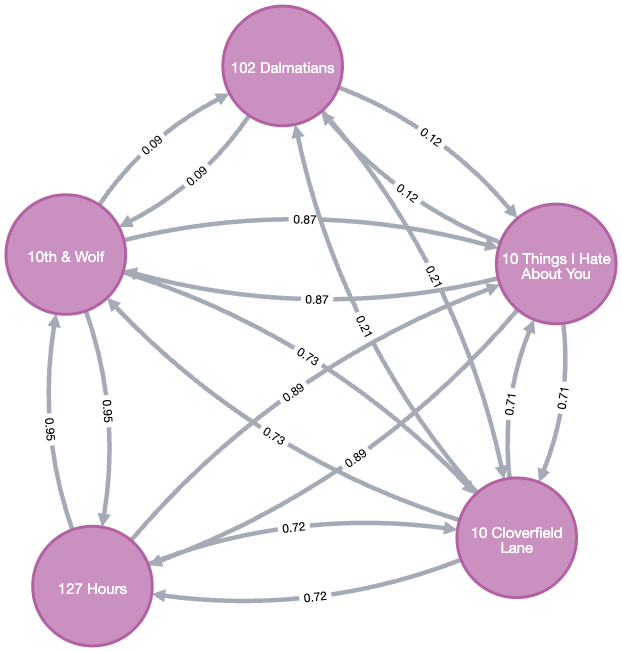

# All movies in cleanmovies

In [59]:
# start fresh
my_neo4j_wipe_out_database()

my_neo4j_create_movie_nodes(movies_df, len(movies_df))
my_neo4j_create_top_3_similarity_links(movies_df, len(movies_df), similarities)
    
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,(500) Days of Summer,[Movie]
1,10 Cloverfield Lane,[Movie]
2,10 Things I Hate About You,[Movie]
3,102 Dalmatians,[Movie]
4,10th & Wolf,[Movie]
...,...,...
3218,[REC]²,[Movie]
3219,eXistenZ,[Movie]
3220,xXx,[Movie]
3221,xXx: State of the Union,[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,movie_title_2,node_2_labels
0,(500) Days of Summer,[Movie],SIMILAR,Agora,[Movie]
1,(500) Days of Summer,[Movie],SIMILAR,Alatriste,[Movie]
2,(500) Days of Summer,[Movie],SIMILAR,Amélie,[Movie]
3,10 Cloverfield Lane,[Movie],SIMILAR,102 Dalmatians,[Movie]
4,10 Cloverfield Lane,[Movie],SIMILAR,10th & Wolf,[Movie]
...,...,...,...,...,...
17467,xXx: State of the Union,[Movie],SIMILAR,Zodiac,[Movie]
17468,Æon Flux,[Movie],SIMILAR,3000 Miles to Graceland,[Movie]
17469,Æon Flux,[Movie],SIMILAR,A Perfect Getaway,[Movie]
17470,Æon Flux,[Movie],SIMILAR,Argo,[Movie]


-------------------------
  Density: 0.0
-------------------------


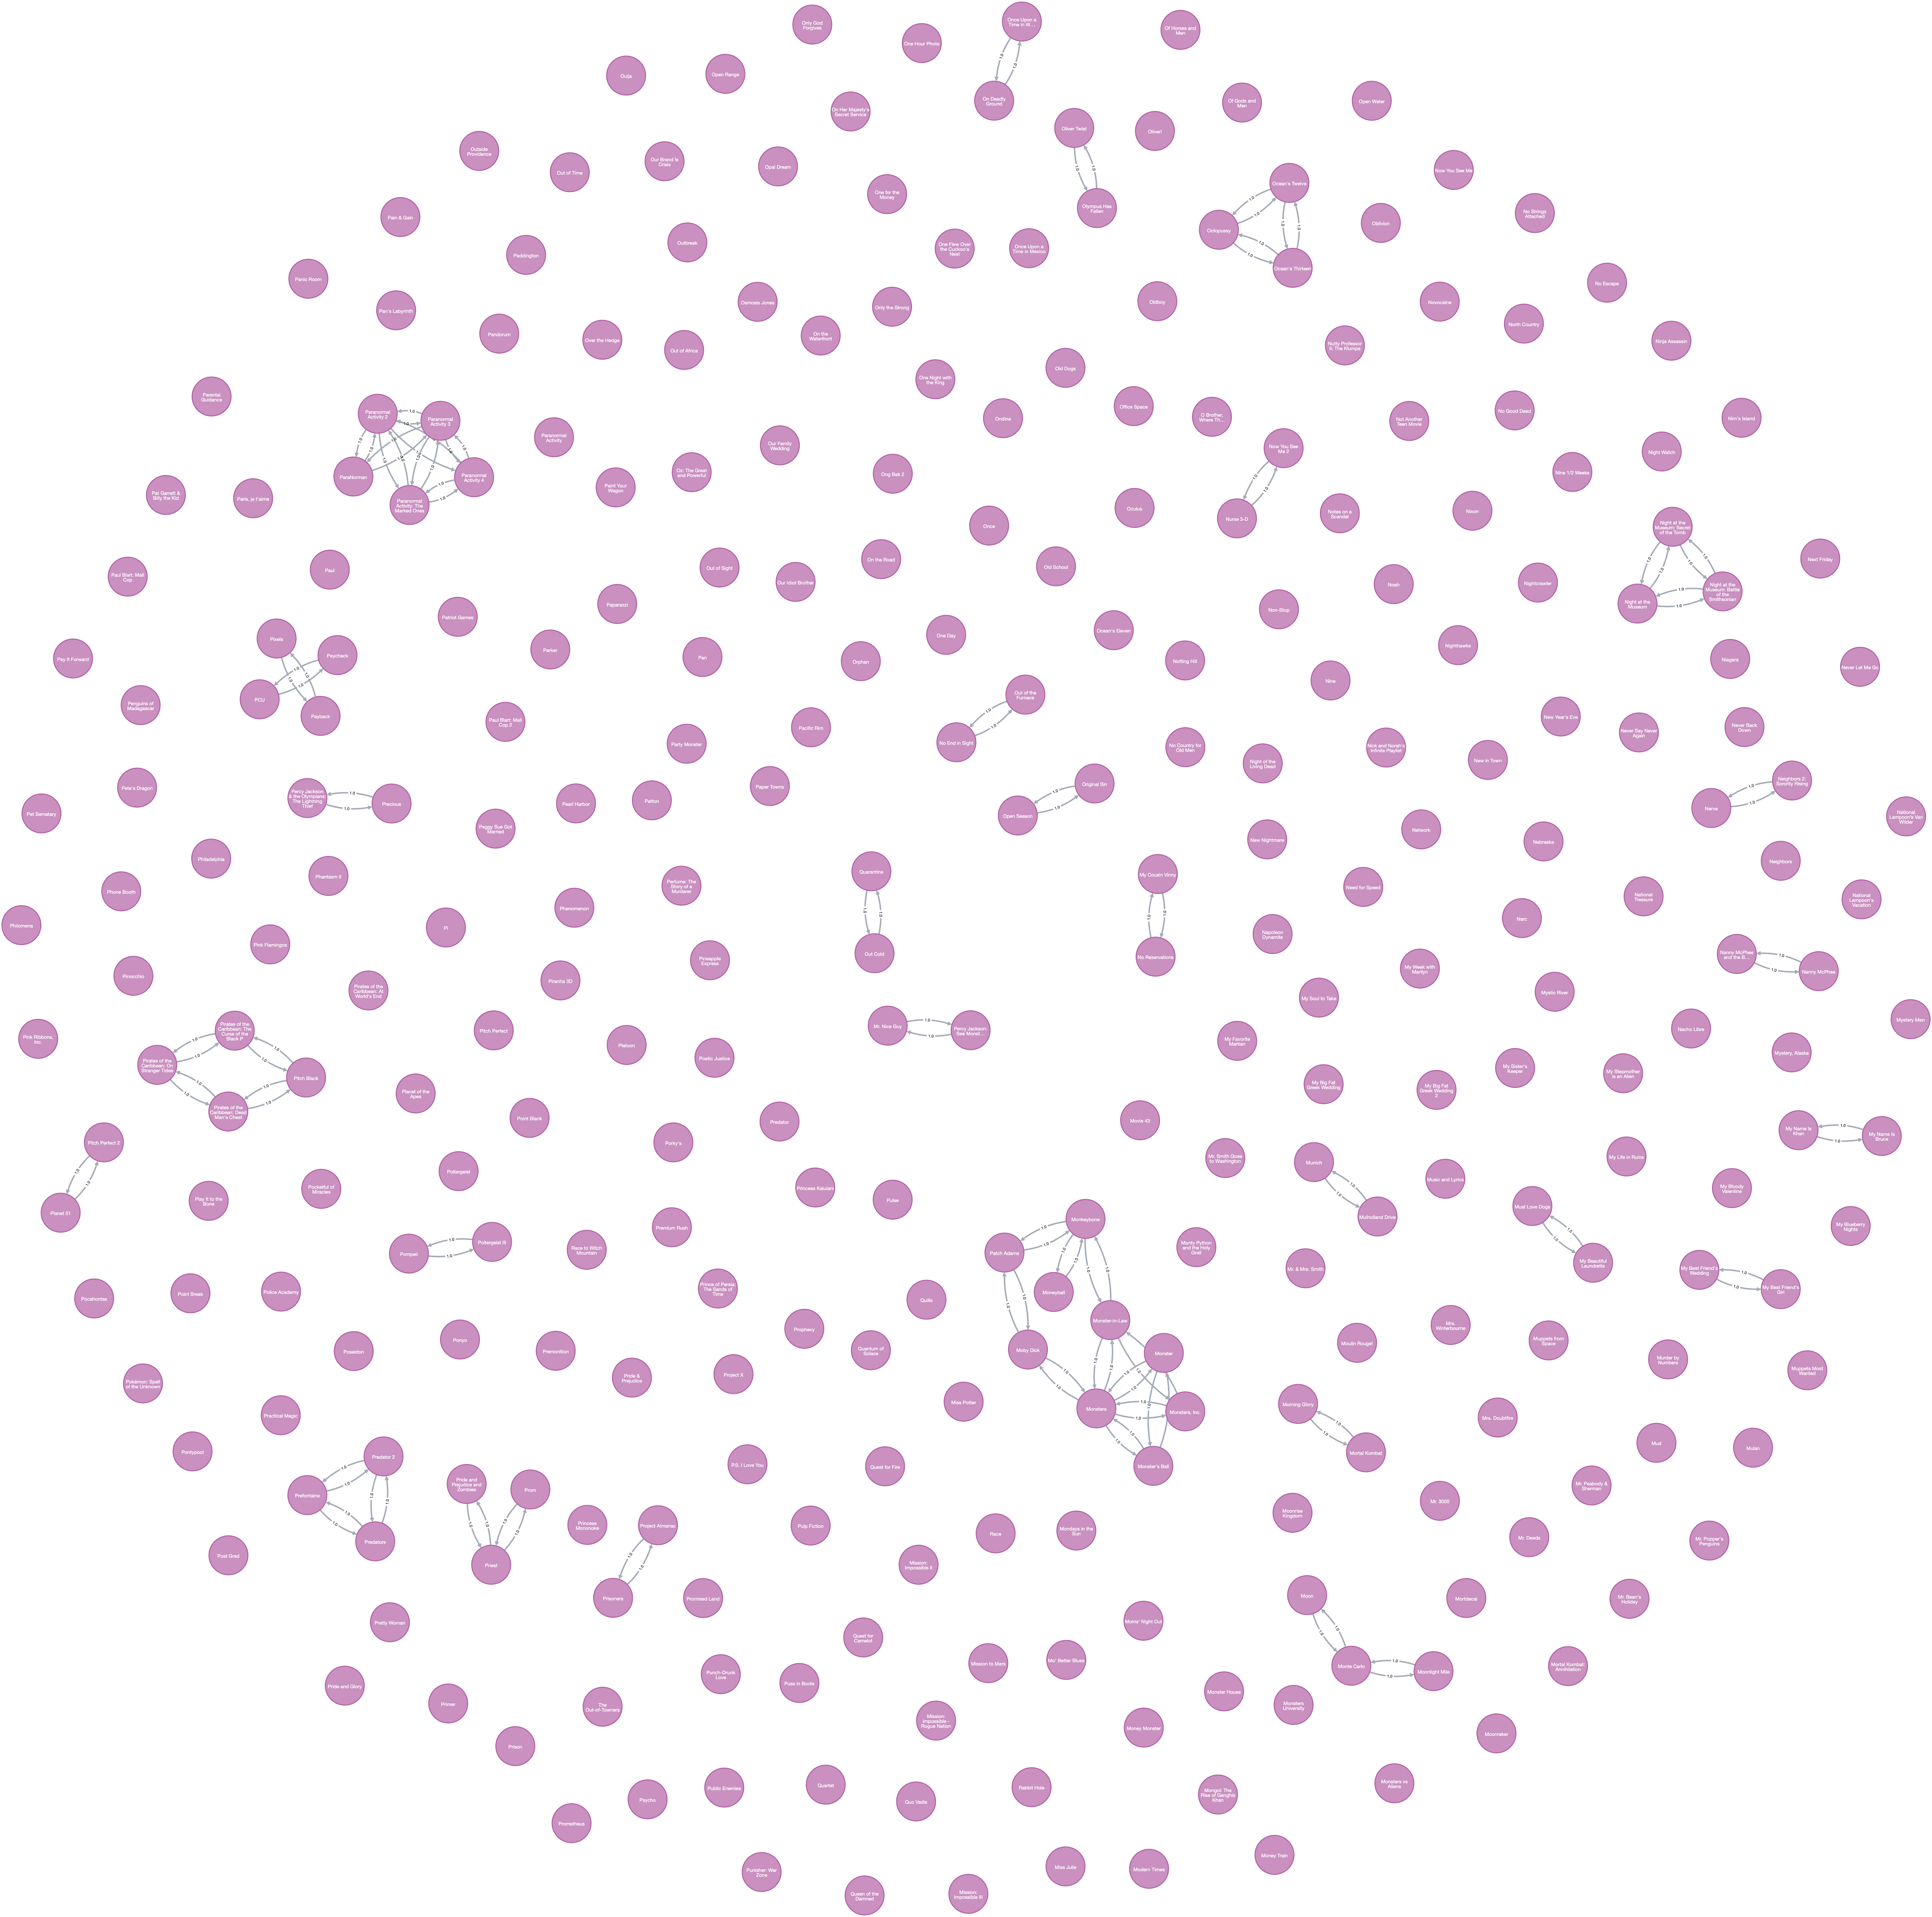